In [2]:
# 如果需要，可取消注释并改成你的路径
import sys
# sys.path.append(r'.')

from importlib import reload
import os
import low_cut_utils_modified as ref 
reload(ref)
from low_cut_utils_modified import *
import numpy as np
from scipy.signal import peak_prominences
from lgdo import lh5
import numpy as np
import awkward as ak
from lgdo import lh5
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator


In [71]:
filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "05"
run_cal = "057"

# bg run 6 days
pnum_phy_bg = "00"
run_phy_bg = "038"
# signal run 13 days
pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
   's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw3', 's60ns_mw5', 's60ns_mw7',
    's60ns_mw1', 's100ns_mw1', 's200ns_mw1',
]



def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)

        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")
        missing_this_run = []
        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")
        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "time_ns": int(m.group(1)),
            "mw": int(m.group(2)),
            "interval": f"{m.group(1)}ns",
            "mw_label": f"mw{m.group(2)}",
            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,
            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,
            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )
    return db
run_db = build_run_db(runs, filepath)


In [72]:
all_db = load_pkl("all_lowcut_event_fix_db_r57r59.pkl")

loaded from all_lowcut_event_fix_db_r57r59.pkl


In [73]:
run = "s100ns_mw3"
channel = "ch002"
event_db = all_db[run][channel]["event_db"]
aoe_field = 'A_max_mw_o_E_fix_Corrected'
energy_field = 'trap'

In [74]:
print(all_db.keys())

for run in all_db:
    print(run, all_db[run].keys())
for run in event_db:
    print(run, event_db[run].keys())

dict_keys(['s100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7', 's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7', 's60ns_mw1', 's60ns_mw3', 's60ns_mw5', 's60ns_mw7'])
s100ns_mw1 dict_keys(['ch002'])
s100ns_mw3 dict_keys(['ch002'])
s100ns_mw5 dict_keys(['ch002'])
s100ns_mw7 dict_keys(['ch002'])
s200ns_mw1 dict_keys(['ch002'])
s200ns_mw3 dict_keys(['ch002'])
s200ns_mw5 dict_keys(['ch002'])
s200ns_mw7 dict_keys(['ch002'])
s60ns_mw1 dict_keys(['ch002'])
s60ns_mw3 dict_keys(['ch002'])
s60ns_mw5 dict_keys(['ch002'])
s60ns_mw7 dict_keys(['ch002'])
meta dict_keys(['run', 'channel', 'aoe_field', 'low_cut_field', 'energy_field', 'windows', 'peak_db', 'use_fitted_peaks', 'window_nsigma', 'survival_fep', 'survival_dep', 'survival_compton_signal', 'survival_compton_bg_subtracted'])
events dict_keys(['DEP', 'FEP', 'ROI_BG', 'ROI_Signal'])


In [75]:
hist_db = make_hist_db_from_event_db(
    event_db,
    bins=250,    
    value_range=(0.75, 1.25),
    
)

In [76]:
run = "s100ns_mw3"
channel = "ch002"

event_db = all_db[run][channel]["event_db"]

hist_db = make_hist_db_from_event_db(
    event_db,
    bins=250,
    value_range=(0.75, 1.25),
    
)


## some fit functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def _propagate_uncertainty_numeric(func, popt, pcov, eps=1e-6):
    """
    Numerical Gaussian error propagation.

    func(p) must return one scalar quantity calculated from fit parameters p.
    sigma_f^2 = grad^T @ pcov @ grad
    """
    popt = np.asarray(popt, dtype=float)
    pcov = np.asarray(pcov, dtype=float)

    if pcov.shape != (len(popt), len(popt)):
        return np.nan

    if not np.all(np.isfinite(pcov)):
        return np.nan

    grad = np.zeros_like(popt, dtype=float)

    for i in range(len(popt)):
        step = eps * max(abs(popt[i]), 1.0)

        p_hi = popt.copy()
        p_lo = popt.copy()
        p_hi[i] += step
        p_lo[i] -= step

        grad[i] = (func(p_hi) - func(p_lo)) / (2 * step)

    var = float(grad @ pcov @ grad)

    if not np.isfinite(var) or var < 0:
        return np.nan

    return float(np.sqrt(var))

def _local_parabola_refit(
    centers,
    counts,
    coarse_idx,
    n_bins_refit=10,
    n_bins_left=None,
    n_bins_right=None,
    kind="peak",
    use_poisson_errors=True,
):
    """
    Refit a local parabola around a coarse peak/valley bin.

    kind:
        "peak"   -> expect downward parabola, a < 0
        "valley" -> expect upward parabola, a > 0

    Returns vertex position, vertex count, curvature, and their uncertainties.
    """
    centers = np.asarray(centers, dtype=float)
    counts = np.asarray(counts, dtype=float)
    if n_bins_left is None and n_bins_right is None:
        n_bins_left = n_bins_refit // 2
        n_bins_right = n_bins_refit - n_bins_left - 1

    elif n_bins_left is not None and n_bins_right is None:
        n_bins_right = n_bins_refit - n_bins_left - 1

    elif n_bins_left is None and n_bins_right is not None:
        n_bins_left = n_bins_refit - n_bins_right - 1

    if n_bins_left < 0 or n_bins_right < 0:
        raise ValueError(
            f"Invalid bin choice: n_bins_refit={n_bins_refit}, "
            f"n_bins_left={n_bins_left}, n_bins_right={n_bins_right}."
            )
    i0 = coarse_idx - n_bins_left
    i1 = coarse_idx + n_bins_right + 1

    # Edge handling: do not shift to preserve symmetry.
    # Just clip to valid histogram range.
    i0 = max(i0, 0)
    i1 = min(i1, len(centers))
    x = centers[i0:i1]
    y = counts[i0:i1]

    if len(x) < 3:
        raise ValueError("Need at least 3 bins for local parabola fit.")

    yerr = np.sqrt(np.maximum(y, 1.0)) if use_poisson_errors else None

    # shifted coordinate for numerical stability
    x0 = np.mean(x)
    u = x - x0

    def parabola_shifted(u, a, b, c):
        return a * u**2 + b * u + c

    p0 = np.polyfit(u, y, 2)

    popt, pcov = curve_fit(
        parabola_shifted,
        u,
        y,
        p0=p0,
        sigma=yerr,
        absolute_sigma=use_poisson_errors,
        maxfev=20000,
    )

    a, b, c = popt

    if np.isclose(a, 0):
        raise RuntimeError(f"{kind} parabola is almost flat; vertex unstable.")

    u_vertex = -b / (2 * a)
    x_vertex = x0 + u_vertex
    y_vertex = parabola_shifted(u_vertex, *popt)
    curvature = 2 * a

    # ---- uncertainty propagation from pcov ----
    def vertex_x_from_p(p):
        aa, bb, cc = p
        return x0 - bb / (2 * aa)

    def vertex_y_from_p(p):
        aa, bb, cc = p
        uu = -bb / (2 * aa)
        return aa * uu**2 + bb * uu + cc

    def curvature_from_p(p):
        aa, bb, cc = p
        return 2 * aa
    
    x_err = _propagate_uncertainty_numeric(vertex_x_from_p, popt, pcov)
    count_err = _propagate_uncertainty_numeric(vertex_y_from_p, popt, pcov)
    curvature_err = _propagate_uncertainty_numeric(curvature_from_p, popt, pcov)

    if kind == "peak" and a >= 0:
        print("[WARN] peak fit opens upward.")
    if kind == "valley" and a <= 0:
        print("[WARN] valley fit opens downward.")

    return {
        "x": float(x_vertex),
        "x_err": float(x_err),
        "n_bins_left": int(n_bins_left),
        "n_bins_right": int(n_bins_right),

        "count": float(y_vertex),
        "count_err": float(count_err),

        "curvature": float(curvature),
        "curvature_err": float(curvature_err),

        "a": float(a),
        "b": float(b),
        "c": float(c),
        "x0": float(x0),

        "coarse_x": float(centers[coarse_idx]),
        "coarse_count": float(counts[coarse_idx]),

        "fit_bin_indices": (int(i0), int(i1)),
        "fit_x": x,
        "fit_y": y,
        "fit_yerr": yerr,

        "popt": popt,
        "pcov": pcov,
    }


def _gaussian_peak(x, A, mu, sigma, C):
    return C + A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def _gaussian_valley(x, A, mu, sigma, C):
    return C - A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)




def _gaussian_fit_peak_or_valley(
    x_fit,
    y_fit,
    yerr_fit=None,
    kind="peak",
):
    """
    Gaussian refit using the same local bins as the parabola fit.

    Returns short internal keys:
        x, x_err, count, count_err, sigma, sigma_err, A, A_err, C, C_err
    """
    x_fit = np.asarray(x_fit, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)

    good = np.isfinite(x_fit) & np.isfinite(y_fit)

    if yerr_fit is not None:
        yerr_fit = np.asarray(yerr_fit, dtype=float)
        good &= np.isfinite(yerr_fit) & (yerr_fit > 0)

    x_fit = x_fit[good]
    y_fit = y_fit[good]

    if yerr_fit is not None:
        yerr_fit = yerr_fit[good]

    fail = {
        "x": np.nan,
        "x_err": np.nan,
        "count": np.nan,
        "count_err": np.nan,
        "sigma": np.nan,
        "sigma_err": np.nan,
        "A": np.nan,
        "A_err": np.nan,
        "C": np.nan,
        "C_err": np.nan,
        "popt": None,
        "pcov": None,
        "success": False,
    }

    if len(x_fit) < 4:
        return fail.copy()

    x_min = float(np.min(x_fit))
    x_max = float(np.max(x_fit))
    dx = x_max - x_min

    if dx <= 0:
        return fail.copy()

    C0 = float(np.median(y_fit))

    if kind == "peak":
        model = _gaussian_peak
        mu0 = float(x_fit[np.argmax(y_fit)])
        A0 = float(np.max(y_fit) - C0)
    elif kind == "valley":
        model = _gaussian_valley
        mu0 = float(x_fit[np.argmin(y_fit)])
        A0 = float(C0 - np.min(y_fit))
    else:
        raise ValueError("kind must be 'peak' or 'valley'")

    A0 = max(A0, 1.0)
    sigma0 = dx / 4.0

    lower = [0.0, x_min, dx / 100.0, 0.0]
    upper = [np.inf, x_max, dx * 2.0, np.inf]

    try:
        popt, pcov = curve_fit(
            model,
            x_fit,
            y_fit,
            p0=[A0, mu0, sigma0, C0],
            sigma=yerr_fit,
            absolute_sigma=(yerr_fit is not None),
            bounds=(lower, upper),
            maxfev=20000,
        )

        A, mu, sigma, C = popt

        if pcov is None or not np.all(np.isfinite(pcov)):
            perr = np.full(4, np.nan)
        else:
            perr = np.sqrt(np.diag(pcov))

        # count at fitted center
        count = float(model(mu, *popt))

        def count_from_p(p):
            A_, mu_, sigma_, C_ = p
            return model(mu_, A_, mu_, sigma_, C_)

        count_err = _propagate_uncertainty_numeric(count_from_p, popt, pcov)

        return {
            "x": float(mu),
            "x_err": float(perr[1]),
            "count": float(count),
            "count_err": float(count_err),
            "sigma": abs(float(sigma)),
            "sigma_err": float(perr[2]),
            "A": float(A),
            "A_err": float(perr[0]),
            "C": float(C),
            "C_err": float(perr[3]),
            "popt": popt,
            "pcov": pcov,
            "success": True,
        }

    except Exception as e:
        print(f"[WARN] {kind} gaussian fit failed: {e}")
        return fail.copy()

def peak_valley_parabola_refit_from_hist_item(
    hist_item,
    counts_key="counts",
    peak_range=(0.980, 1.10),
    valley_range=(0.95, 1.000),
    n_bins_refit=10,
    peak_bins_left=None,
    peak_bins_right=None,
    valley_bins_left=None,
    valley_bins_right=None,
    use_poisson_errors=True,
    plot_gaus=False,
    plot=False,
    title=None,
):
    """
    Find peak and valley with local parabola refits.

    Steps:
      1. Find coarse peak in peak_range.
      2. Refit nearby n_bins_refit bins with parabola.
      3. Find coarse valley in valley_range.
      4. Refit nearby n_bins_refit bins with parabola.
      5. Return peak, valley, curvature, P/V ratio, and uncertainties.

    This uses bin-center fits, not integral fits.
    """
    centers = np.asarray(hist_item["centers"], dtype=float)
    counts = np.asarray(hist_item[counts_key], dtype=float)

    finite = np.isfinite(centers) & np.isfinite(counts)
    centers = centers[finite]
    counts = counts[finite]

    peak_mask = (centers >= peak_range[0]) & (centers <= peak_range[1])
    valley_mask = (centers >= valley_range[0]) & (centers <= valley_range[1])

    if np.count_nonzero(peak_mask) < 3:
        raise ValueError("Not enough bins in peak_range.")
    if np.count_nonzero(valley_mask) < 3:
        raise ValueError("Not enough bins in valley_range.")

    peak_indices = np.where(peak_mask)[0]
    valley_indices = np.where(valley_mask)[0]

    coarse_peak_idx = peak_indices[np.argmax(counts[peak_mask])]
    coarse_valley_idx = valley_indices[np.argmin(counts[valley_mask])]

    peak_fit = _local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_peak_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=peak_bins_left,
        n_bins_right=peak_bins_right,
        kind="peak",
        use_poisson_errors=use_poisson_errors,
        )
    valley_fit = _local_parabola_refit(
        centers=centers,
        counts=counts,
        coarse_idx=coarse_valley_idx,
        n_bins_refit=n_bins_refit,
        n_bins_left=valley_bins_left,
        n_bins_right=valley_bins_right,
        kind="valley",
        use_poisson_errors=use_poisson_errors,
    )
    peak_g = _gaussian_fit_peak_or_valley(
        peak_fit["fit_x"],
        peak_fit["fit_y"],
        peak_fit["fit_yerr"] if use_poisson_errors else None,
        kind="peak",
    )

    valley_g = _gaussian_fit_peak_or_valley(
        valley_fit["fit_x"],
        valley_fit["fit_y"],
        valley_fit["fit_yerr"] if use_poisson_errors else None,
        kind="valley",
    )
    peak_count = peak_fit["count"]
    peak_count_err = peak_fit["count_err"]

    valley_count = valley_fit["count"]
    valley_count_err = valley_fit["count_err"]

    ratio = (peak_count - valley_count) / peak_count if peak_count > 0 else np.inf

    if peak_count > 0 and valley_count > 0:
        ratio_err = ratio * np.sqrt(
            (peak_count_err / peak_count) ** 2
            + (valley_count_err / valley_count) ** 2
        )
    else:
        ratio_err = np.nan

    peak_count_g = peak_g["count"]
    peak_count_err_g = peak_g["count_err"]

    valley_count_g = valley_g["count"]
    valley_count_err_g = valley_g["count_err"]

    if np.isfinite(peak_count_g) and np.isfinite(valley_count_g) and valley_count_g > 0:
        ratio_g = (peak_count_g - valley_count_g) / peak_count_g if peak_count_g > 0 else np.inf

        if peak_count_g > 0:
            ratio_err_g = ratio_g * np.sqrt(
                (peak_count_err_g / peak_count_g) ** 2
                + (valley_count_err_g / valley_count_g) ** 2
            )
        else:
            ratio_err_g = np.nan
    else:
        ratio_g = np.nan
        ratio_err_g = np.nan
        
    if plot or plot_gaus:
        def eval_fit(x, fit):
            u = x - fit["x0"]
            a, b, c = fit["popt"]
            return a * u**2 + b * u + c

        fig, ax = plt.subplots(figsize=(8, 5))
        bin_width = np.median(np.diff(centers))

        # -----------------------------
        # main plot
        # -----------------------------
        ax.step(
            centers,
            counts,
            where="mid",
            label=f"hist {counts_key}",
            alpha=0.75,
        )

        # actual fit-window boundaries
        peak_xmin = peak_fit["fit_x"][0] - bin_width / 2
        peak_xmax = peak_fit["fit_x"][-1] + bin_width / 2

        valley_xmin = valley_fit["fit_x"][0] - bin_width / 2
        valley_xmax = valley_fit["fit_x"][-1] + bin_width / 2

        # full zoom range from both peak and valley fit windows
        inset_xmin = min(peak_xmin, valley_xmin)
        inset_xmax = max(peak_xmax, valley_xmax)

        # small padding in x
        inset_dx = inset_xmax - inset_xmin
        inset_xmin -= 0.10 * inset_dx
        inset_xmax += 0.10 * inset_dx

        # -----------------------------
        # shaded fit ranges on main plot
        # -----------------------------
        ax.axvspan(
            peak_xmin,
            peak_xmax,
            color="lightskyblue",
            alpha=0.25,
            label=f"peak fit range ({len(peak_fit['fit_x'])} bins)",
        )

        ax.axvspan(
            valley_xmin,
            valley_xmax,
            color="lightgreen",
            alpha=0.20,
            label=f"valley fit range ({len(valley_fit['fit_x'])} bins)",
        )

        # fit curve x ranges: actual fitted bin ranges only
        xp = np.linspace(peak_xmin, peak_xmax, 300)
        xv = np.linspace(valley_xmin, valley_xmax, 300)

        # -----------------------------
        # main plot fit curves
        # -----------------------------
        if plot:
            yp = eval_fit(xp, peak_fit)
            yv = eval_fit(xv, valley_fit)

            ax.plot(
                xp,
                yp,
                linewidth=2,
                label="peak parabola",
                alpha=0.5,
            )

            ax.plot(
                xv,
                yv,
                linewidth=2,
                label="valley parabola",
                alpha=0.5,
            )

        if plot_gaus:
            if peak_g["success"]:
                ypg = _gaussian_peak(xp, *peak_g["popt"])

                ax.plot(
                    xp,
                    ypg,
                    linewidth=2,
                    linestyle="-",
                    label="peak gaussian",
                    alpha=0.8,
                )

            if valley_g["success"]:
                yvg = _gaussian_valley(xv, *valley_g["popt"])

                ax.plot(
                    xv,
                    yvg,
                    linewidth=2,
                    linestyle="-",
                    label="valley inverted gaussian",
                    alpha=0.8,
                )

        # -----------------------------
        # vertical lines on main plot
        # -----------------------------
        if plot:
            ax.axvline(
                peak_fit["x"],
                linestyle="--",
                label=(
                    f"peak parabola: {peak_fit['x']:.3f} ± {peak_fit['x_err']:.3f}, "
                    f"{peak_fit['count']:.1f} ± {peak_fit['count_err']:.1f}"
                ),
            )

            ax.axvline(
                valley_fit["x"],
                linestyle="--",
                label=(
                    f"valley parabola: {valley_fit['x']:.3f} ± {valley_fit['x_err']:.3f}, "
                    f"{valley_fit['count']:.1f} ± {valley_fit['count_err']:.1f}"
                ),
            )

        if plot_gaus and peak_g["success"]:
            ax.axvline(
                peak_g["x"],
                linestyle=":",
                label=(
                    f"peak gaussian: {peak_g['x']:.3f} ± {peak_g['x_err']:.3f}, "
                    f"{peak_g['count']:.1f} ± {peak_g['count_err']:.1f}"
                ),
            )

        if plot_gaus and valley_g["success"]:
            ax.axvline(
                valley_g["x"],
                linestyle=":",
                label=(
                    f"valley gaussian: {valley_g['x']:.3f} ± {valley_g['x_err']:.3f}, "
                    f"{valley_g['count']:.1f} ± {valley_g['count_err']:.1f}"
                ),
            )

        # -----------------------------
        # inset: automatically zoom using peak/valley fit ranges and counts
        # -----------------------------
        axins = ax.inset_axes([0.05, 0.05, 0.38, 0.32])
        # [left, bottom, width, height] in axes fraction
        # larger left/bottom -> move inset right/up

        inset_mask = (centers >= inset_xmin) & (centers <= inset_xmax)

        axins.step(
            centers[inset_mask],
            counts[inset_mask],
            where="mid",
            alpha=0.75,
        )

        # same shaded regions in inset
        axins.axvspan(
            peak_xmin,
            peak_xmax,
            color="lightskyblue",
            alpha=0.25,
        )

        axins.axvspan(
            valley_xmin,
            valley_xmax,
            color="lightgreen",
            alpha=0.20,
        )

        y_candidates = []

        # histogram counts inside inset range
        hist_y = counts[inset_mask]
        hist_y = hist_y[np.isfinite(hist_y)]
        if len(hist_y) > 0:
            y_candidates.extend(hist_y.tolist())

        # inset curves over actual fit ranges
        if plot:
            yp = eval_fit(xp, peak_fit)
            yv = eval_fit(xv, valley_fit)

            axins.plot(
                xp,
                yp,
                linewidth=1.7,
                alpha=0.5,
            )

            axins.plot(
                xv,
                yv,
                linewidth=1.7,
                alpha=0.5,
            )

            y_candidates.extend(yp[np.isfinite(yp)].tolist())
            y_candidates.extend(yv[np.isfinite(yv)].tolist())

            axins.axvline(
                peak_fit["x"],
                linestyle="--",
                linewidth=1.2,
            )

            axins.axvline(
                valley_fit["x"],
                linestyle="--",
                linewidth=1.2,
            )

            y_candidates.append(peak_fit["count"])
            y_candidates.append(valley_fit["count"])

        if plot_gaus:
            if peak_g["success"]:
                ypg = _gaussian_peak(xp, *peak_g["popt"])

                axins.plot(
                    xp,
                    ypg,
                    linewidth=1.7,
                    linestyle="-",
                    alpha=0.8,
                )

                axins.axvline(
                    peak_g["x"],
                    linestyle=":",
                    linewidth=1.3,
                )

                y_candidates.extend(ypg[np.isfinite(ypg)].tolist())
                y_candidates.append(peak_g["count"])

            if valley_g["success"]:
                yvg = _gaussian_valley(xv, *valley_g["popt"])

                axins.plot(
                    xv,
                    yvg,
                    linewidth=1.7,
                    linestyle="-",
                    alpha=0.8,
                )

                axins.axvline(
                    valley_g["x"],
                    linestyle=":",
                    linewidth=1.3,
                )

                y_candidates.extend(yvg[np.isfinite(yvg)].tolist())
                y_candidates.append(valley_g["count"])

        # automatic y-range from histogram + fitted counts + fit curves
        y_candidates = np.asarray(y_candidates, dtype=float)
        y_candidates = y_candidates[np.isfinite(y_candidates)]

        if len(y_candidates) > 0:
            y_min = np.min(y_candidates)
            y_max = np.max(y_candidates)

            dy = y_max - y_min
            if dy <= 0:
                dy = max(abs(y_max), 1.0) * 0.2

            inset_ymin = max(0.0, y_min - 0.15 * dy)
            inset_ymax = y_max + 0.20 * dy
        else:
            inset_ymin, inset_ymax = 0.0, 1.0

        axins.set_xlim(inset_xmin, inset_xmax)
        axins.set_ylim(inset_ymin, inset_ymax)

        axins.grid(alpha=0.25)
        axins.tick_params(labelsize=7)
        axins.xaxis.set_major_locator(MaxNLocator(4))
        axins.yaxis.set_major_locator(MaxNLocator(4))
        axins.set_title("fit zoom", fontsize=8)

        for spine in axins.spines.values():
            spine.set_linewidth(1.1)

        # -----------------------------
        # main plot style
        # -----------------------------
        ax.set_xlabel("A/E")
        ax.set_ylabel("Counts")
        ax.set_yscale("log")
        ax.grid(alpha=0.3)

        if title is None:
            title_use = "Peak Valley fit"
        else:
            title_use = f"{title}\nPeak Valley fit"

        ax.set_title(title_use)

        ax.legend(
            fontsize=9,
            loc="upper right",
            bbox_to_anchor=(0.98, 0.98),
        )

        fig.tight_layout()
        plt.show()
    return {
        "ratio": float(ratio),
        "ratio_err": float(ratio_err),

        "peak_x": peak_fit["x"],
        "peak_x_err": peak_fit["x_err"],
        "peak_count": peak_fit["count"],
        "peak_count_err": peak_fit["count_err"],
        "peak_curvature": peak_fit["curvature"],
        "peak_curvature_err": peak_fit["curvature_err"],
        "peak_coarse_x": peak_fit["coarse_x"],
        "peak_coarse_count": peak_fit["coarse_count"],

        "valley_x": valley_fit["x"],
        "valley_x_err": valley_fit["x_err"],
        "valley_count": valley_fit["count"],
        "valley_count_err": valley_fit["count_err"],
        "valley_curvature": valley_fit["curvature"],
        "valley_curvature_err": valley_fit["curvature_err"],
        "valley_coarse_x": valley_fit["coarse_x"],
        "valley_coarse_count": valley_fit["coarse_count"],

        "peak_fit": peak_fit,
        "valley_fit": valley_fit,

        "counts_key": counts_key,
        "peak_range": peak_range,
        "valley_range": valley_range,
        "n_bins_refit": n_bins_refit,
        "peak_bins_left": peak_fit["n_bins_left"],
        "peak_bins_right": peak_fit["n_bins_right"],
        "valley_bins_left": valley_fit["n_bins_left"],
        "valley_bins_right": valley_fit["n_bins_right"],
                
        "ratio_gaussian": float(ratio_g),
        "ratio_gaussian_err": float(ratio_err_g),

        "peak_x_gaussian": peak_g["x"],
        "peak_x_err_gaussian": peak_g["x_err"],
        "peak_count_gaussian": peak_g["count"],
        "peak_count_err_gaussian": peak_g["count_err"],
        "peak_sigma_gaussian": peak_g["sigma"],
        "peak_sigma_err_gaussian": peak_g["sigma_err"],
        "peak_A_gaussian": peak_g["A"],
        "peak_A_err_gaussian": peak_g["A_err"],
        "peak_C_gaussian": peak_g["C"],
        "peak_C_err_gaussian": peak_g["C_err"],
        "peak_fit_success_gaussian": peak_g["success"],

        "valley_x_gaussian": valley_g["x"],
        "valley_x_err_gaussian": valley_g["x_err"],
        "valley_count_gaussian": valley_g["count"],
        "valley_count_err_gaussian": valley_g["count_err"],
        "valley_sigma_gaussian": valley_g["sigma"],
        "valley_sigma_err_gaussian": valley_g["sigma_err"],
        "valley_A_gaussian": valley_g["A"],
        "valley_A_err_gaussian": valley_g["A_err"],
        "valley_C_gaussian": valley_g["C"],
        "valley_C_err_gaussian": valley_g["C_err"],
        "valley_fit_success_gaussian": valley_g["success"],

        "peak_fit_gaussian": peak_g,
        "valley_fit_gaussian": valley_g,
    }

## Plots

### fix

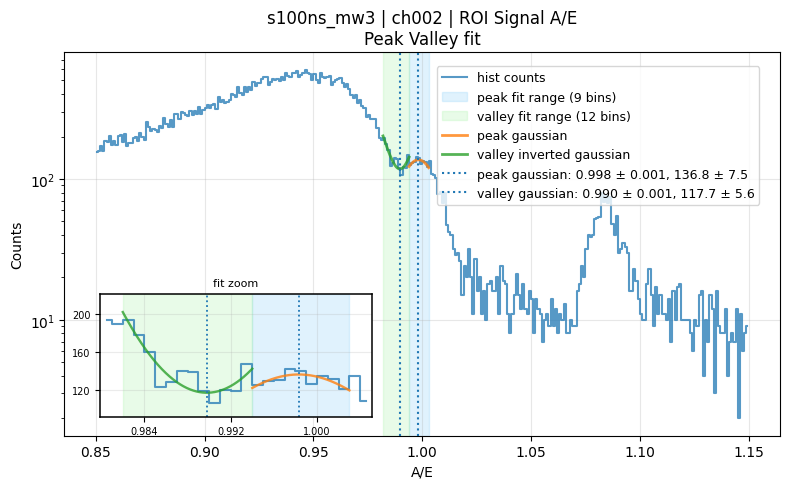

s100ns_mw3
P/V ratio = 0.1381878581754296 +/- 0.007992781876488785
peak A/E = 0.9983105123050171 +/- 0.0009650887974863858
peak count = 136.68192582548016 +/- 5.85032293304543
peak curvature = -1532896.6353360016 +/- 1293960.8377895567
valley A/E = 0.9897896718962228 +/- 0.000537967473187462
valley count = 117.79414324436412 +/- 4.582497448531407
valley curvature = 2801722.9196406505 +/- 672430.0916486788


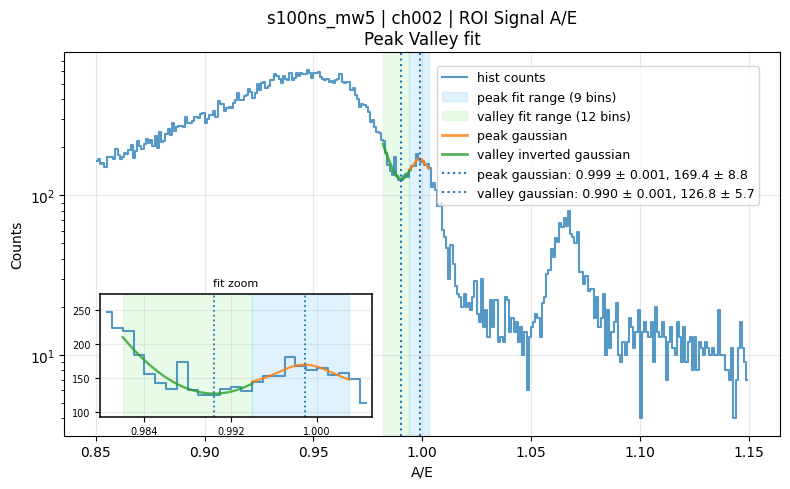

s100ns_mw5
P/V ratio = 0.24144327172799127 +/- 0.012700769166958286
peak A/E = 0.998953443087169 +/- 0.0007222860656009413
peak count = 167.3345409746098 +/- 6.419175614361059
peak curvature = -2405984.4994581467 +/- 1430017.5981916508
valley A/E = 0.9904897317931165 +/- 0.0008061450501645876
valley count = 126.9327419285984 +/- 4.568767744681227
valley curvature = 2330415.649656395 +/- 683624.8885214888


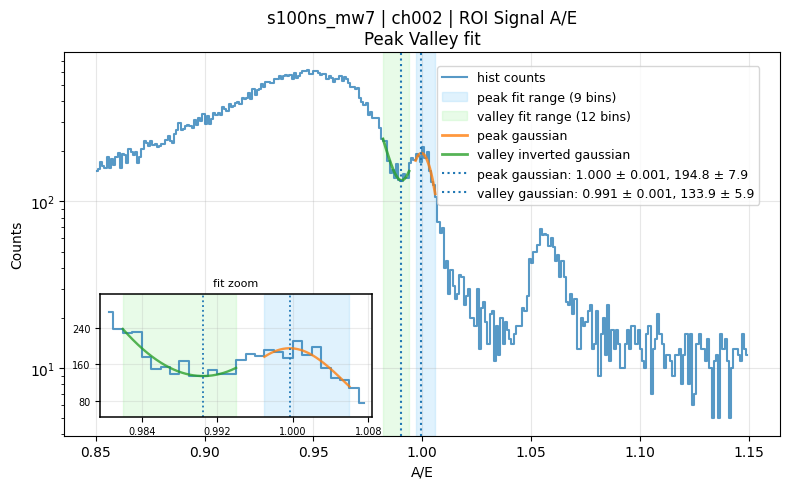

s100ns_mw7
P/V ratio = 0.305711727366273 +/- 0.014426784669869358
peak A/E = 0.9995174132071444 +/- 0.0008553124614805934
peak count = 193.0674446500093 +/- 6.074745731945543
peak curvature = -4129046.414397084 +/- 1481658.6303900813
valley A/E = 0.9905218233866687 +/- 0.0006784032716435975
valley count = 134.04446264786264 +/- 4.714414626105366
valley curvature = 2868270.633832464 +/- 706591.2947522103


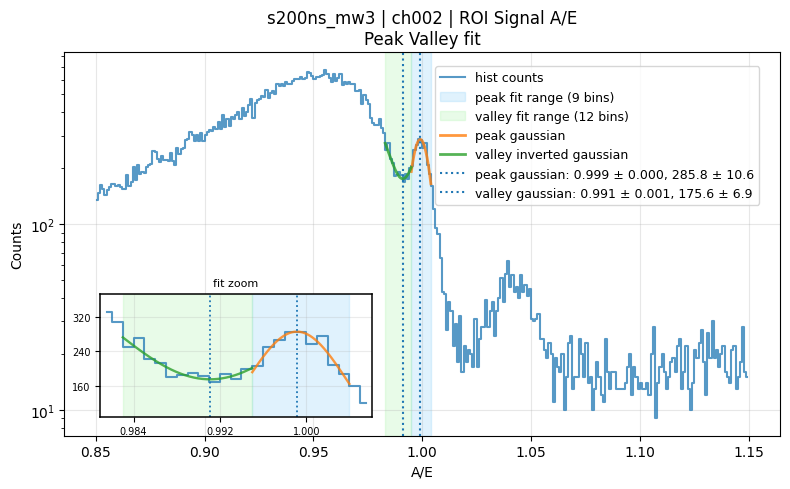

s200ns_mw3
P/V ratio = 0.37580285782380063 +/- 0.01584310050448523
peak A/E = 0.9991718253016342 +/- 0.0001826864570725311
peak count = 283.3813908311086 +/- 8.216865674653873
peak curvature = -10910102.037999708 +/- 1718189.6079148245
valley A/E = 0.9911197928205041 +/- 0.0006508313758503563
valley count = 176.8858543026946 +/- 5.413233934527695
valley curvature = 3058128.348356106 +/- 789901.1048051264


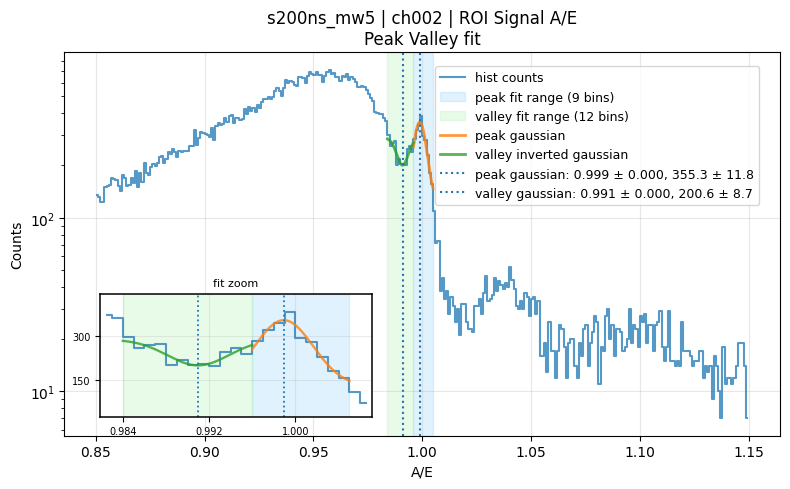

s200ns_mw5
P/V ratio = 0.36079626577353147 +/- 0.01378177336103948
peak A/E = 0.9986997617350646 +/- 0.00035757205970466895
peak count = 329.24478594681244 +/- 7.860556437029387
peak curvature = -11325163.72593828 +/- 1793806.1574551812
valley A/E = 0.9909524505308969 +/- 0.0003527068412246166
valley count = 210.45449665179683 +/- 6.275326890996695
valley curvature = 4367016.127789325 +/- 852886.098031375


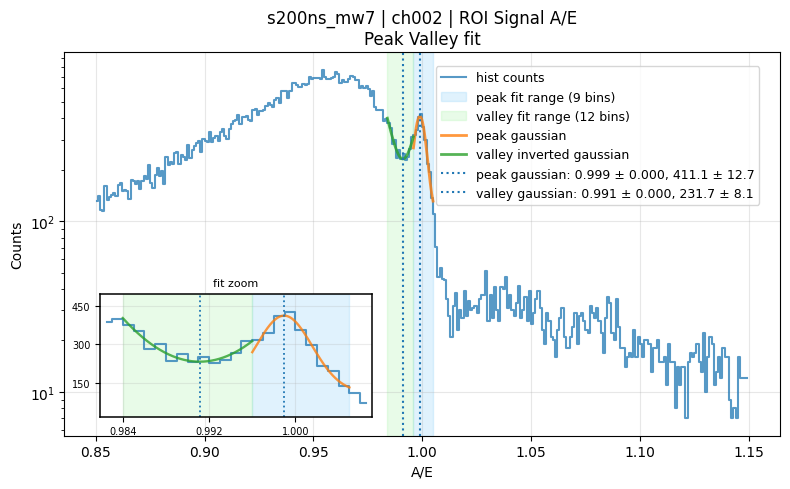

s200ns_mw7
P/V ratio = 0.3739683339335998 +/- 0.013610393048883286
peak A/E = 0.9986523101133937 +/- 0.0002923372383962442
peak count = 370.4423658196409 +/- 8.235893374363865
peak curvature = -14681248.11257864 +/- 1826546.6130424887
valley A/E = 0.9911246361503551 +/- 0.0002595292208180718
valley count = 231.90865145564868 +/- 6.682318299710918
valley curvature = 6743251.867527694 +/- 944826.3394147627
[WARN] peak fit opens upward.


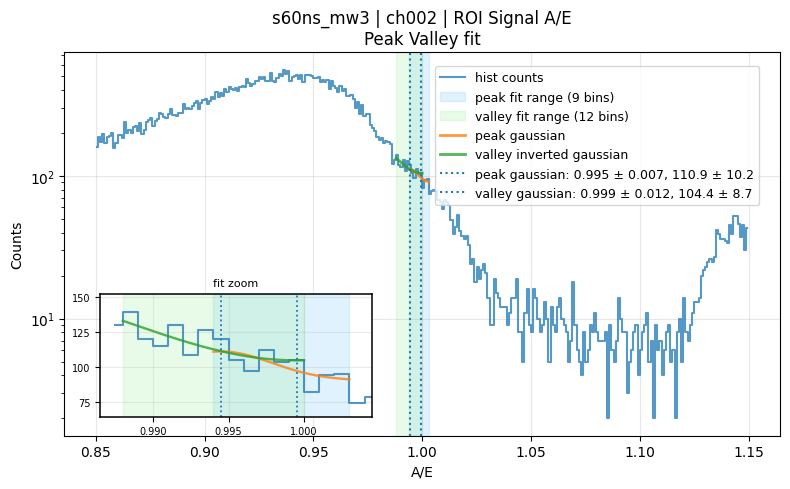

s60ns_mw3
P/V ratio = -0.11768614402593527 +/- -0.02416126244663637
peak A/E = 1.003443345536483 +/- 0.010155144797642192
peak count = 91.93343877828401 +/- 12.28409268050069
peak curvature = 576052.8703207463 +/- 1169189.4977707015
valley A/E = 1.0018174363427035 +/- 0.014540070565515721
valley count = 102.75273069514465 +/- 16.01591006737646
valley curvature = 320823.6290619135 +/- 593085.3043402346
[WARN] peak fit opens upward.
[WARN] peak gaussian fit failed: Optimal parameters not found: The maximum number of function evaluations is exceeded.


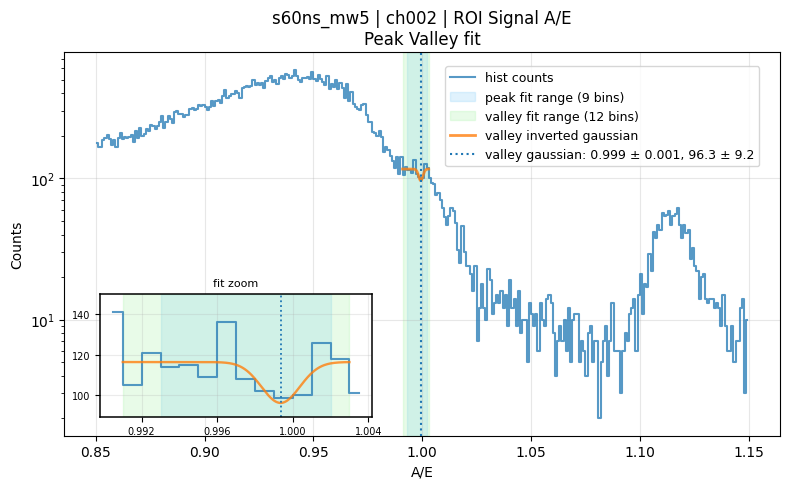

s60ns_mw5
P/V ratio = -0.024993922009900537 +/- -0.001533668965982904
peak A/E = 0.9986346543145885 +/- 0.002284368362472842
peak count = 107.63211695236983 +/- 4.95661854469262
peak curvature = 871367.5111593492 +/- 1228056.4946463848
valley A/E = 0.9978748483407209 +/- 0.004493893737296382
valley count = 110.32226568923785 +/- 4.4738587723828545
valley curvature = 231997.60350382587 +/- 582373.2193699125
[WARN] peak fit opens upward.


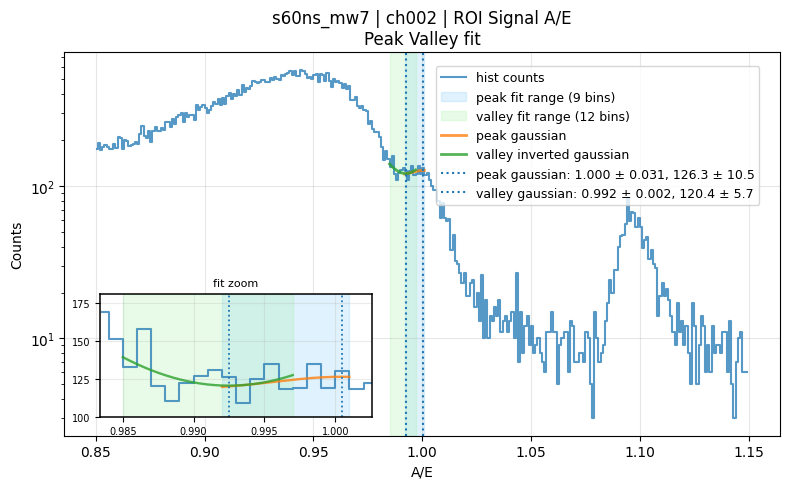

s60ns_mw7
P/V ratio = -0.0563933703220954 +/- -0.1392330661871563
peak A/E = 0.9753947519375517 +/- 0.6431940335736713
peak count = 114.01814180101994 +/- 281.4731391914062
peak curvature = 41947.823218027195 +/- 1277633.6869297838
valley A/E = 0.9924992371122596 +/- 0.0019210360807701205
valley count = 120.44800909504204 +/- 4.5722857924174445
valley curvature = 674775.9189693608 +/- 616917.0777852302
[WARN] peak fit opens upward.
[WARN] valley fit opens downward.


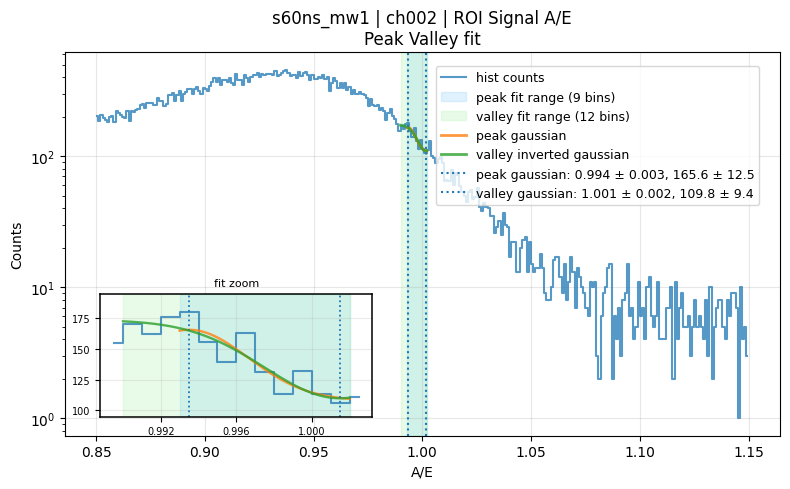

s60ns_mw1
P/V ratio = -0.8468926632070177 +/- -0.39914574060623836
peak A/E = 1.0058195429411376 +/- 0.011237652476778586
peak count = 99.2818259621256 +/- 41.74446309072957
peak curvature = 973306.4347968809 +/- 1328304.1820013828
valley A/E = 0.9848965172391682 +/- 0.012702244753749781
valley count = 183.36287595924577 +/- 39.04350021737857
valley curvature = -578207.0426648391 +/- 644699.3414366837


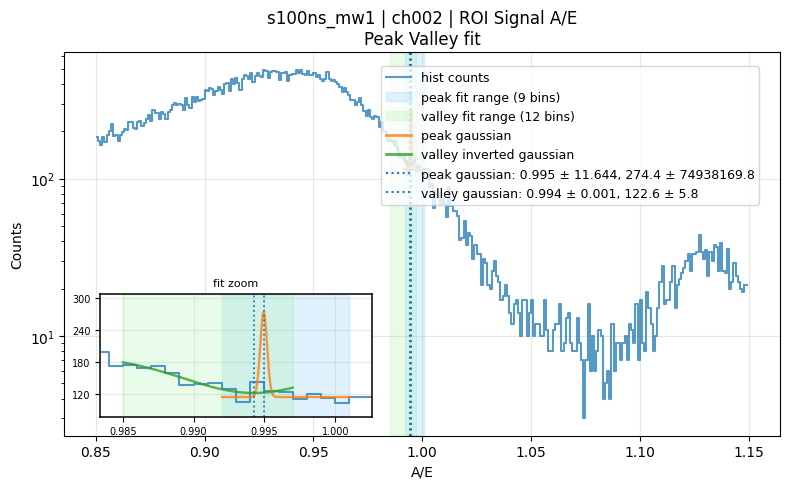

s100ns_mw1
P/V ratio = 0.004924786535463998 +/- 0.00030690455283638647
peak A/E = 0.9948840260717454 +/- 0.0019776991107427503
peak count = 125.1264080226403 +/- 5.040946929537016
peak curvature = -1258094.2001358827 +/- 1239059.5976011695
valley A/E = 0.9955018420097159 +/- 0.0026056816675864127
valley count = 124.51018717317943 +/- 5.919863303757778
valley curvature = 1162165.5641567083 +/- 654147.0759673791
[WARN] peak fit opens upward.


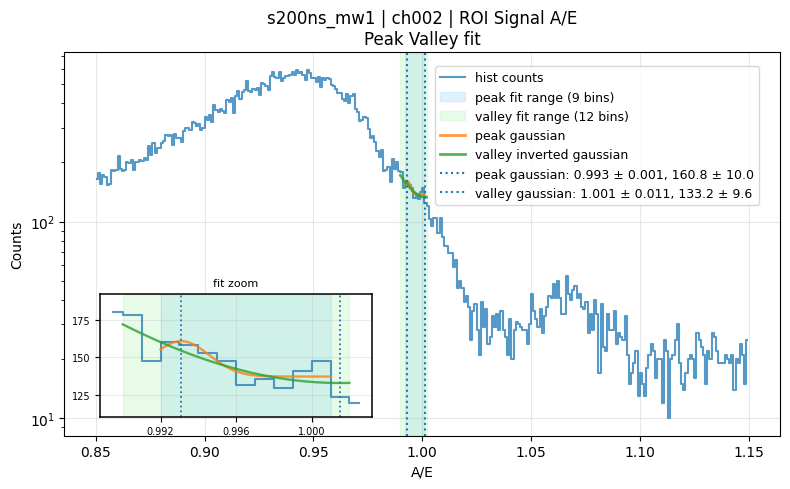

s200ns_mw1
P/V ratio = 0.022329140304544838 +/- 0.0018547861919857487
peak A/E = 0.9977053768464336 +/- 0.001032459781792916
peak count = 135.99441431379606 +/- 5.567505649455492
peak curvature = 2206235.1598286503 +/- 1382625.8728269534
valley A/E = 1.0018338065138672 +/- 0.006966816744940163
valley count = 132.9577759559489 +/- 9.609724508157143
valley curvature = 561281.66559048 +/- 659818.0508685415


In [ ]:
results = []
pvr_db = {}

for run in runs:
    event_db = all_db[run][channel]["event_db"]

    hist_db = make_hist_db_from_event_db(
        event_db,
        bins=300,
        value_range=(0.85, 1.15),
    )

    pvr = peak_valley_parabola_refit_from_hist_item(
        hist_db["ROI_Signal"],
        counts_key="counts",
        peak_range=(0.995, 1.010),
        valley_range=(0.95, 1.000),
        # n_bins_refit=11,
        peak_bins_left=3,
        peak_bins_right=5,
        valley_bins_left=8,
        valley_bins_right=3,
        use_poisson_errors=True,
        # plot=True,
        plot_gaus=True,
        title=f"{run} | {channel} | ROI Signal A/E",
    )

    print(run)
    print("P/V ratio =", pvr["ratio"], "+/-", pvr["ratio_err"])
    print("peak A/E =", pvr["peak_x"], "+/-", pvr["peak_x_err"])
    print("peak count =", pvr["peak_count"], "+/-", pvr["peak_count_err"])
    print("peak curvature =", pvr["peak_curvature"], "+/-", pvr["peak_curvature_err"])
    print("valley A/E =", pvr["valley_x"], "+/-", pvr["valley_x_err"])
    print("valley count =", pvr["valley_count"], "+/-", pvr["valley_count_err"])
    print("valley curvature =", pvr["valley_curvature"], "+/-", pvr["valley_curvature_err"])

    row = {
        "run": run,
        "channel": channel,

        "ratio": pvr["ratio"],
        "ratio_err": pvr["ratio_err"],

        "peak_x": pvr["peak_x"],
        "peak_x_err": pvr["peak_x_err"],
        "peak_count": pvr["peak_count"],
        "peak_count_err": pvr["peak_count_err"],
        "peak_curvature": pvr["peak_curvature"],
        "peak_curvature_err": pvr["peak_curvature_err"],

        "valley_x": pvr["valley_x"],
        "valley_x_err": pvr["valley_x_err"],
        "valley_count": pvr["valley_count"],
        "valley_count_err": pvr["valley_count_err"],
        "valley_curvature": pvr["valley_curvature"],
        "valley_curvature_err": pvr["valley_curvature_err"],
        
        
        "ratio_gaussian": pvr["ratio_gaussian"],
        "ratio_gaussian_err": pvr["ratio_gaussian_err"],

        "peak_x_gaussian": pvr["peak_x_gaussian"],
        "peak_x_err_gaussian": pvr["peak_x_err_gaussian"],
        "peak_count_gaussian": pvr["peak_count_gaussian"],
        "peak_count_err_gaussian": pvr["peak_count_err_gaussian"],
        "peak_sigma_gaussian": pvr["peak_sigma_gaussian"],
        "peak_sigma_err_gaussian": pvr["peak_sigma_err_gaussian"],
        "peak_A_gaussian": pvr["peak_A_gaussian"],
        "peak_A_err_gaussian": pvr["peak_A_err_gaussian"],
        "peak_C_gaussian": pvr["peak_C_gaussian"],
        "peak_C_err_gaussian": pvr["peak_C_err_gaussian"],
        "peak_fit_success_gaussian": pvr["peak_fit_success_gaussian"],

        "valley_x_gaussian": pvr["valley_x_gaussian"],
        "valley_x_err_gaussian": pvr["valley_x_err_gaussian"],
        "valley_count_gaussian": pvr["valley_count_gaussian"],
        "valley_count_err_gaussian": pvr["valley_count_err_gaussian"],
        "valley_sigma_gaussian": pvr["valley_sigma_gaussian"],
        "valley_sigma_err_gaussian": pvr["valley_sigma_err_gaussian"],
        "valley_A_gaussian": pvr["valley_A_gaussian"],
        "valley_A_err_gaussian": pvr["valley_A_err_gaussian"],
        "valley_C_gaussian": pvr["valley_C_gaussian"],
        "valley_C_err_gaussian": pvr["valley_C_err_gaussian"],
        "valley_fit_success_gaussian": pvr["valley_fit_success_gaussian"],
    }

    results.append(row)

    if run not in pvr_db:
        pvr_db[run] = {}

    pvr_db[run][channel] = {
        "summary": row,
        "full_result": pvr,
    }


In [79]:
def survival_optic_from_hist_item(hist_item, cut_x, counts_key="counts"):
    """
    Count ROI_Signal events left of cut_x and divide by total ROI_Signal counts.

    survival_optic = N(A/E < cut_x) / N(total)

    Uses histogram bin centers.
    """
    centers = np.asarray(hist_item["centers"], dtype=float)
    counts = np.asarray(hist_item[counts_key], dtype=float)

    finite = np.isfinite(centers) & np.isfinite(counts)
    centers = centers[finite]
    counts = counts[finite]

    total = np.sum(counts)

    if not np.isfinite(cut_x) or total <= 0:
        return {
            "eps": np.nan,
            "eps_err": np.nan,
            "n_left": np.nan,
            "n_total": float(total),
            "cut_x": float(cut_x) if np.isfinite(cut_x) else np.nan,
        }

    left = np.sum(counts[centers < cut_x])

    eps = left / total
    eps_err = np.sqrt(eps * (1.0 - eps) / total)

    return {
        "eps": float(eps),
        "eps_err": float(eps_err),
        "n_left": float(left),
        "n_total": float(total),
        "cut_x": float(cut_x),
    }

In [80]:
for row in results:
    run = row["run"]
    channel = row["channel"]

    event_db = all_db[run][channel]["event_db"]

    hist_db = make_hist_db_from_event_db(
        event_db,
        bins=300,
        value_range=(0.85, 1.15),
    )

    # use already fitted valley positions from the row
    survival_optic = survival_optic_from_hist_item(
        hist_db["ROI_Signal"],
        cut_x=row["valley_x"],
        counts_key="counts",
    )

    survival_optic_gaussian = survival_optic_from_hist_item(
        hist_db["ROI_Signal"],
        cut_x=row["valley_x_gaussian"],
        counts_key="counts",
    )

    # add new columns to existing row
    row["survival_optic"] = survival_optic["eps"]
    row["survival_optic_err"] = survival_optic["eps_err"]
    row["survival_optic_n_left"] = survival_optic["n_left"]
    row["survival_optic_n_total"] = survival_optic["n_total"]
    row["survival_optic_cut_x"] = survival_optic["cut_x"]

    row["survival_optic_gaussian"] = survival_optic_gaussian["eps"]
    row["survival_optic_err_gaussian"] = survival_optic_gaussian["eps_err"]
    row["survival_optic_n_left_gaussian"] = survival_optic_gaussian["n_left"]
    row["survival_optic_n_total_gaussian"] = survival_optic_gaussian["n_total"]
    row["survival_optic_cut_x_gaussian"] = survival_optic_gaussian["cut_x"]

    # also add to pvr_db
    pvr_db[run][channel]["summary"] = row
    pvr_db[run][channel]["full_result"]["survival_optic"] = survival_optic
    pvr_db[run][channel]["full_result"]["survival_optic_gaussian"] = survival_optic_gaussian

    print(run, channel)
    print(
        "survival_optic =",
        survival_optic["eps"],
        "+/-",
        survival_optic["eps_err"],
        f"({survival_optic['n_left']:.0f} / {survival_optic['n_total']:.0f})",
    )
    print(
        "survival_optic_gaussian =",
        survival_optic_gaussian["eps"],
        "+/-",
        survival_optic_gaussian["eps_err"],
        f"({survival_optic_gaussian['n_left']:.0f} / {survival_optic_gaussian['n_total']:.0f})",
    )

s100ns_mw3 ch002
survival_optic = 0.9048761437179201 +/- 0.001265205870468653 (48657 / 53772)
survival_optic_gaussian = 0.9048761437179201 +/- 0.001265205870468653 (48657 / 53772)
s100ns_mw5 ch002
survival_optic = 0.8995655230849664 +/- 0.0012762408572301912 (49898 / 55469)
survival_optic_gaussian = 0.8995655230849664 +/- 0.0012762408572301912 (49898 / 55469)
s100ns_mw7 ch002
survival_optic = 0.898345652939106 +/- 0.0012677513981897482 (51044 / 56820)
survival_optic_gaussian = 0.898345652939106 +/- 0.0012677513981897482 (51044 / 56820)
s200ns_mw3 ch002
survival_optic = 0.8881014858518159 +/- 0.001288784568737361 (53136 / 59831)
survival_optic_gaussian = 0.8881014858518159 +/- 0.001288784568737361 (53136 / 59831)
s200ns_mw5 ch002
survival_optic = 0.88407058254774 +/- 0.0012851443363355603 (54861 / 62055)
survival_optic_gaussian = 0.88407058254774 +/- 0.0012851443363355603 (54861 / 62055)
s200ns_mw7 ch002
survival_optic = 0.8806638691121693 +/- 0.0012851988923931275 (56034 / 63627)
survi

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 如果你已经有 results list
pvr_df = pd.DataFrame(results).copy()

# 看看现在有哪些列
print(pvr_df.columns.tolist())
pvr_df.head()

['run', 'channel', 'ratio', 'ratio_err', 'peak_x', 'peak_x_err', 'peak_count', 'peak_count_err', 'peak_curvature', 'peak_curvature_err', 'valley_x', 'valley_x_err', 'valley_count', 'valley_count_err', 'valley_curvature', 'valley_curvature_err', 'ratio_gaussian', 'ratio_gaussian_err', 'peak_x_gaussian', 'peak_x_err_gaussian', 'peak_count_gaussian', 'peak_count_err_gaussian', 'peak_sigma_gaussian', 'peak_sigma_err_gaussian', 'peak_A_gaussian', 'peak_A_err_gaussian', 'peak_C_gaussian', 'peak_C_err_gaussian', 'peak_fit_success_gaussian', 'valley_x_gaussian', 'valley_x_err_gaussian', 'valley_count_gaussian', 'valley_count_err_gaussian', 'valley_sigma_gaussian', 'valley_sigma_err_gaussian', 'valley_A_gaussian', 'valley_A_err_gaussian', 'valley_C_gaussian', 'valley_C_err_gaussian', 'valley_fit_success_gaussian', 'survival_optic', 'survival_optic_err', 'survival_optic_n_left', 'survival_optic_n_total', 'survival_optic_cut_x', 'survival_optic_gaussian', 'survival_optic_err_gaussian', 'survival_

,run,channel,ratio,ratio_err,peak_x,peak_x_err,peak_count,peak_count_err,peak_curvature,peak_curvature_err,...,survival_optic,survival_optic_err,survival_optic_n_left,survival_optic_n_total,survival_optic_cut_x,survival_optic_gaussian,survival_optic_err_gaussian,survival_optic_n_left_gaussian,survival_optic_n_total_gaussian,survival_optic_cut_x_gaussian
0,s100ns_mw3,ch002,0.138188,0.007993,0.998311,0.000965,136.681926,5.850323,-1.532897e+06,1.293961e+06,...,0.904876,0.001265,48657.0,53772.0,0.989790,0.904876,0.001265,48657.0,53772.0,0.989793
1,s100ns_mw5,ch002,0.241443,0.012701,0.998953,0.000722,167.334541,6.419176,-2.405984e+06,1.430018e+06,...,0.899566,0.001276,49898.0,55469.0,0.990490,0.899566,0.001276,49898.0,55469.0,0.990476
2,s100ns_mw7,ch002,0.305712,0.014427,0.999517,0.000855,193.067445,6.074746,-4.129046e+06,1.481659e+06,...,0.898346,0.001268,51044.0,56820.0,0.990522,0.898346,0.001268,51044.0,56820.0,0.990504
3,s200ns_mw3,ch002,0.375803,0.015843,0.999172,0.000183,283.381391,8.216866,-1.091010e+07,1.718190e+06,...,0.888101,0.001289,53136.0,59831.0,0.991120,0.888101,0.001289,53136.0,59831.0,0.991090
4,s200ns_mw5,ch002,0.360796,0.013782,0.998700,0.000358,329.244786,7.860556,-1.132516e+07,1.793806e+06,...,0.884071,0.001285,54861.0,62055.0,0.990952,0.884071,0.001285,54861.0,62055.0,0.990975


In [82]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pvr_df = pvr_df.copy()

def parse_window_mw(run):
    """
    Parse run name like:
        s60ns_mw1
        s100ns_mw3
        s200ns_mw5
    """
    m = re.search(r"s(\d+)ns_mw(\d+)", str(run))
    if m is None:
        return pd.Series({"window_ns": np.nan, "mw": np.nan})
    
    return pd.Series({
        "window_ns": int(m.group(1)),
        "mw": int(m.group(2)),
    })

pvr_df[["window_ns", "mw"]] = pvr_df["run"].apply(parse_window_mw)

pvr_df[["run", "window_ns", "mw"]].head()

,run,window_ns,mw
0,s100ns_mw3,100,3
1,s100ns_mw5,100,5
2,s100ns_mw7,100,7
3,s200ns_mw3,200,3
4,s200ns_mw5,200,5


In [83]:
import numpy as np
import pandas as pd

pvr_df = pvr_df.copy()

def safe_get_survival(event_db, meta_key):
    """
    Read:
        event_db["meta"][meta_key]["eps"]
        event_db["meta"][meta_key]["sigma"]
    """
    try:
        item = event_db["meta"][meta_key]
    except Exception:
        return np.nan, np.nan

    try:
        eps = float(item["eps"])
    except Exception:
        eps = np.nan

    try:
        sigma = float(item["sigma"])
    except Exception:
        sigma = np.nan

    return eps, sigma

In [84]:
survival_keys = [
    "survival_dep",
    "survival_fep",
    "survival_compton_signal",
    "survival_roi_bg",
    "survival_compton_signal",
]

for key in survival_keys:
    eps_vals = []
    err_vals = []

    for _, row in pvr_df.iterrows():
        run = row["run"]
        channel = row["channel"]

        try:
            event_db = all_db[run][channel]["event_db"]
            eps, sigma = safe_get_survival(event_db, key)
        except Exception:
            eps, sigma = np.nan, np.nan

        eps_vals.append(eps)
        err_vals.append(sigma)

    pvr_df[key] = eps_vals
    pvr_df[key + "_err"] = err_vals

pvr_df[
    [
        "run",
        "channel",
        "ratio",
        "ratio_err",
        "survival_dep",
        "survival_dep_err",
        "survival_compton_signal",
        "survival_compton_signal_err",
    ]
].head()

,run,channel,ratio,ratio_err,survival_dep,survival_dep_err,survival_compton_signal,survival_compton_signal_err
0,s100ns_mw3,ch002,0.138188,0.007993,0.913169,0.049506,0.093151,0.001050
1,s100ns_mw5,ch002,0.241443,0.012701,0.921852,0.049955,0.090646,0.001037
2,s100ns_mw7,ch002,0.305712,0.014427,0.918234,0.049766,0.088871,0.001028
3,s200ns_mw3,ch002,0.375803,0.015843,0.927641,0.049812,0.085192,0.001008
4,s200ns_mw5,ch002,0.360796,0.013782,0.924023,0.049445,0.082895,0.000996


In [85]:
run0 = pvr_df.iloc[0]["run"]
channel0 = pvr_df.iloc[0]["channel"]

event_db0 = all_db[run0][channel0]["event_db"]

print(event_db0["meta"]["survival_dep"].keys())

dict_keys(['eps', 'sigma'])


In [86]:
pvr_df["fom"] = (
    pvr_df["ratio"]
)

pvr_df["fom_err"] = pvr_df["fom"] * np.sqrt(
    (pvr_df["survival_dep_err"] / pvr_df["survival_dep"])**2
    + (pvr_df["ratio_err"] / pvr_df["ratio"])**2
    + (pvr_df["survival_compton_signal_err"] / pvr_df["survival_compton_signal"])**2
)

pvr_df["fom_err"] = pvr_df["fom_err"].replace([np.inf, -np.inf], np.nan)

In [87]:
print(pvr_df.columns.tolist())

['run', 'channel', 'ratio', 'ratio_err', 'peak_x', 'peak_x_err', 'peak_count', 'peak_count_err', 'peak_curvature', 'peak_curvature_err', 'valley_x', 'valley_x_err', 'valley_count', 'valley_count_err', 'valley_curvature', 'valley_curvature_err', 'ratio_gaussian', 'ratio_gaussian_err', 'peak_x_gaussian', 'peak_x_err_gaussian', 'peak_count_gaussian', 'peak_count_err_gaussian', 'peak_sigma_gaussian', 'peak_sigma_err_gaussian', 'peak_A_gaussian', 'peak_A_err_gaussian', 'peak_C_gaussian', 'peak_C_err_gaussian', 'peak_fit_success_gaussian', 'valley_x_gaussian', 'valley_x_err_gaussian', 'valley_count_gaussian', 'valley_count_err_gaussian', 'valley_sigma_gaussian', 'valley_sigma_err_gaussian', 'valley_A_gaussian', 'valley_A_err_gaussian', 'valley_C_gaussian', 'valley_C_err_gaussian', 'valley_fit_success_gaussian', 'survival_optic', 'survival_optic_err', 'survival_optic_n_left', 'survival_optic_n_total', 'survival_optic_cut_x', 'survival_optic_gaussian', 'survival_optic_err_gaussian', 'survival_

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_window_mw_heatmap(
    df,
    value_col="fom_shape",
    err_col=None,
    title=None,
    cmap="cividis",
    annotate=True,
    fmt=".3f",
    err_fmt=".3f",
    normalize=None,
    center_zero=False,
    figsize=(8, 6),
    annot_fontsize=11,
    tick_fontsize=11,
    label_fontsize=12,
    title_fontsize=13,
    cbar_fontsize=11,
    adaptive_text_color=True,
    text_color="black",
    bad_color="lightgray",
):
    """
    Heatmap with x = window_ns, y = mw.

    Parameters
    ----------
    value_col : str
        Column used for color values.
    err_col : str or None
        Optional error column. If given, annotations show value ± error.
    normalize :
        None        -> use raw values
        "minmax"    -> (x - min) / (max - min), range [0, 1]
        "zscore"    -> (x - mean) / std
        "relative"  -> x / max(x), range roughly [0, 1]
        "percent"   -> 100 * x / max(x)
    adaptive_text_color : bool
        If True, text color is chosen automatically from cell background.
    """

    d = df.copy()

    required = ["window_ns", "mw", value_col]
    if err_col is not None:
        required.append(err_col)

    for col in required:
        if col not in d.columns:
            raise KeyError(f"Missing column: {col}")

    d = d[
        np.isfinite(d["window_ns"])
        & np.isfinite(d["mw"])
        & np.isfinite(d[value_col])
    ].copy()

    if len(d) == 0:
        raise ValueError("No finite rows to plot.")

    pivot_raw = d.pivot_table(
        index="mw",
        columns="window_ns",
        values=value_col,
        aggfunc="mean",
    )

    pivot = pivot_raw.copy().astype(float)

    pivot_err = None
    if err_col is not None:
        d_err = d[np.isfinite(d[err_col])].copy()

        if len(d_err) > 0:
            pivot_err = d_err.pivot_table(
                index="mw",
                columns="window_ns",
                values=err_col,
                aggfunc="mean",
            )
            pivot_err = pivot_err.reindex(index=pivot.index, columns=pivot.columns)

    vals = pivot.values
    finite_vals = vals[np.isfinite(vals)]

    if len(finite_vals) == 0:
        raise ValueError("No finite values after pivot.")

    if normalize is None:
        plot_values = vals
        cbar_label = value_col

    elif normalize == "minmax":
        vmin = np.nanmin(finite_vals)
        vmax = np.nanmax(finite_vals)
        if vmax == vmin:
            plot_values = np.full_like(vals, np.nan)
        else:
            plot_values = (vals - vmin) / (vmax - vmin)
        cbar_label = f"{value_col} normalized min-max"

    elif normalize == "zscore":
        mean = np.nanmean(finite_vals)
        std = np.nanstd(finite_vals)
        if std == 0:
            plot_values = np.full_like(vals, np.nan)
        else:
            plot_values = (vals - mean) / std
        cbar_label = f"{value_col} z-score"

    elif normalize == "relative":
        vmax = np.nanmax(finite_vals)
        if vmax == 0:
            plot_values = np.full_like(vals, np.nan)
        else:
            plot_values = vals / vmax
        cbar_label = f"{value_col} / max"

    elif normalize == "percent":
        vmax = np.nanmax(finite_vals)
        if vmax == 0:
            plot_values = np.full_like(vals, np.nan)
        else:
            plot_values = 100 * vals / vmax
        cbar_label = f"{value_col} [% of max]"

    else:
        raise ValueError(
            "normalize must be one of None, 'minmax', 'zscore', 'relative', 'percent'"
        )

    fig, ax = plt.subplots(figsize=figsize)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color=bad_color)

    if center_zero:
        vmax_abs = np.nanmax(np.abs(plot_values))
        im = ax.imshow(
            plot_values,
            origin="lower",
            aspect="auto",
            cmap=cmap_obj,
            vmin=-vmax_abs,
            vmax=vmax_abs,
        )
    else:
        im = ax.imshow(
            plot_values,
            origin="lower",
            aspect="auto",
            cmap=cmap_obj,
        )

    cbar = fig.colorbar(im, ax=ax)
    # cbar.set_label(cbar_label, fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=tick_fontsize)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=tick_fontsize)

    ax.set_xlabel("window length [ns]", fontsize=label_fontsize)
    ax.set_ylabel("number of smoothing", fontsize=label_fontsize)

    def choose_text_color(plot_val):
        """
        Choose black/white text depending on cell background brightness.
        """
        if not adaptive_text_color or not np.isfinite(plot_val):
            return text_color

        rgba = im.cmap(im.norm(plot_val))
        r, g, b, _ = rgba

        # perceived luminance
        luminance = 0.299 * r + 0.587 * g + 0.114 * b

        if luminance < 0.5:
            return "white"
        else:
            return "black"

    if annotate:
        for i, mw in enumerate(pivot.index):
            for j, win in enumerate(pivot.columns):
                raw_val = pivot_raw.loc[mw, win]
                plot_val = plot_values[i, j]

                if np.isfinite(plot_val):
                    if normalize is None:
                        val_text = format(raw_val, fmt)
                    elif normalize == "percent":
                        val_text = f"{plot_val:.1f}%"
                    else:
                        val_text = f"{plot_val:.3f}"

                    if err_col is not None and pivot_err is not None:
                        raw_err = pivot_err.loc[mw, win]

                        if np.isfinite(raw_err):
                            text = f"{val_text}\n±{format(raw_err, err_fmt)}"
                        else:
                            text = val_text
                    else:
                        text = val_text

                    ax.text(
                        j,
                        i,
                        text,
                        ha="center",
                        va="center",
                        fontsize=annot_fontsize,
                        color=choose_text_color(plot_val),
                        fontweight="medium",
                    )

    if title is None:
        if normalize is None:
            title = f"{value_col} over window length and MW count"
        else:
            title = f"{value_col} over window length and MW count ({normalize})"

    ax.set_title(title, fontsize=title_fontsize)

    fig.tight_layout()
    plt.show()

    return fig, ax, pivot_raw, plot_values, pivot_err


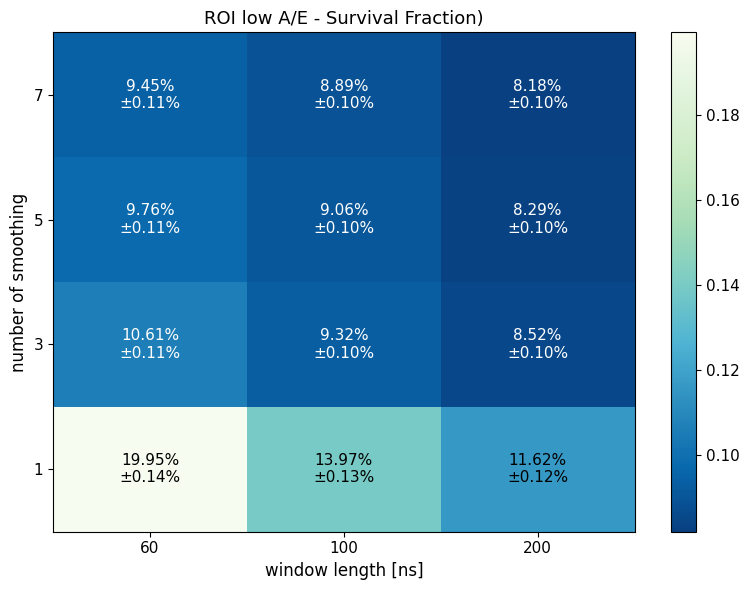

array([[0.19953287, 0.13969389, 0.1162202 ],
       [0.10609481, 0.09315101, 0.08519161],
       [0.09763958, 0.09064575, 0.08289513],
       [0.09450802, 0.0888712 , 0.08182518]], shape=(4, 3))

In [94]:
fig, ax,pivot_raw, compton_matrix,_ = plot_window_mw_heatmap(
    pvr_df,
    value_col="survival_compton_signal",
    err_col="survival_compton_signal_err",
    title=r"ROI low A/E - Survival Fraction)",
    # normalize="percent",
    cmap="GnBu_r",
    annotate=True,
    fmt=".2%",
    err_fmt=".2%"
)

compton_matrix

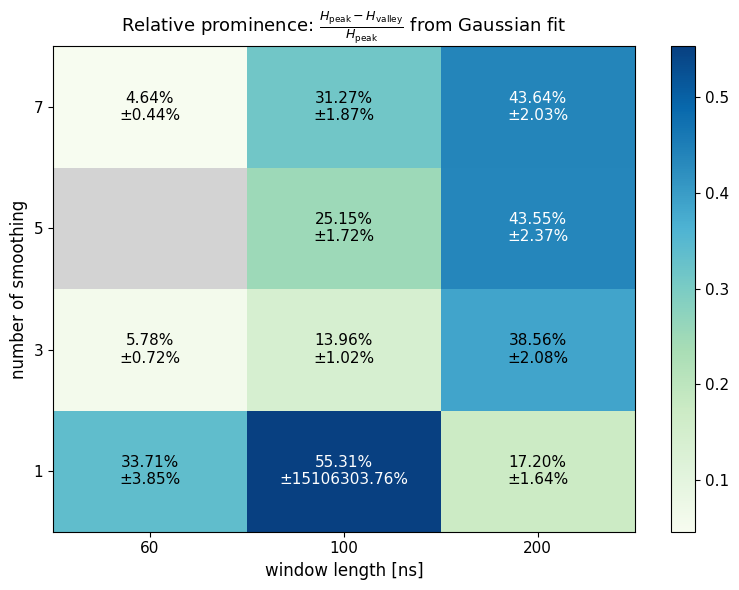

window_ns,60,100,200
mw,,,
1,0.337057,0.553103,0.171999
3,0.057750,0.139638,0.385613
5,NaN,0.251460,0.435524
7,0.046360,0.312651,0.436431


In [90]:
fig, ax,pivot_raw, compton_matrix,_ = plot_window_mw_heatmap(
    pvr_df,
    value_col="ratio_gaussian",
    err_col="ratio_gaussian_err",
    title=r"Relative prominence: $\frac{H_{\mathrm{peak}} - H_{\mathrm{valley}}}{H_{\mathrm{peak}}}$ from Gaussian fit",
    cmap="GnBu",
    # normalize="percent",
    annotate=True,
    fmt=".2%",
    err_fmt=".2%"
)
pivot_raw

In [91]:
curv_ratio_vals = []
curv_ratio_err_vals = []

for _, row in pvr_df.iterrows():
    peak_curv = row["peak_curvature"]
    peak_curv_err = row["peak_curvature_err"]

    valley_curv = row["valley_curvature"]
    valley_curv_err = row["valley_curvature_err"]

    if (
        np.isfinite(peak_curv)
        and np.isfinite(valley_curv)
        and peak_curv != 0
        and valley_curv != 0
    ):
        # valley / peak
        curvature_ratio = abs(valley_curv) / abs(peak_curv)
    else:
        curvature_ratio = np.nan

    if (
        np.isfinite(curvature_ratio)
        and np.isfinite(peak_curv_err)
        and np.isfinite(valley_curv_err)
        and peak_curv != 0
        and valley_curv != 0
    ):
        curvature_ratio_err = curvature_ratio * np.sqrt(
            (valley_curv_err / valley_curv) ** 2
            + (peak_curv_err / peak_curv) ** 2
        )
    else:
        curvature_ratio_err = np.nan

    curv_ratio_vals.append(curvature_ratio)
    curv_ratio_err_vals.append(curvature_ratio_err)

pvr_df["curvature_ratio"] = curv_ratio_vals
pvr_df["curvature_ratio_err"] = curv_ratio_err_vals

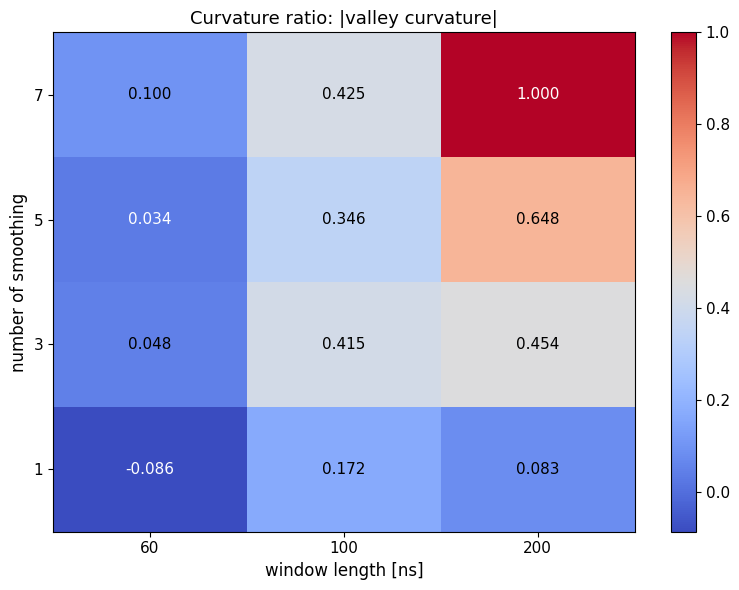

window_ns,60,100,200
mw,,,
1,-578207.042665,1.162166e+06,5.612817e+05
3,320823.629062,2.801723e+06,3.058128e+06
5,231997.603504,2.330416e+06,4.367016e+06
7,674775.918969,2.868271e+06,6.743252e+06


In [92]:
fig, ax, pivot_raw, matrix,_ = plot_window_mw_heatmap(
    pvr_df,
    value_col="valley_curvature",
    # err_col="curvature_ratio_err",
    title=r"Curvature ratio: |valley curvature|",
    normalize="relative",
    cmap="coolwarm",
    annotate=True,
    fmt=".3f",
    err_fmt=".3f"
)
pivot_raw